# Playwright .NET Flaky Test Analyzer
**Workflow:** Load TRX/JUnit XML → Tidy DataFrame → Compute Flakiness Metrics → Visualize

Point `DATA_DIR` at your folder of TRX files (one file per CI run).

In [13]:
import sys
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from trx_parser import load_all

# ── CONFIG ──────────────────────────────────────────────────────────
DATA_DIR = Path('../data/sample')   # <── change to your real data path
FLAKY_THRESHOLD  = 0.05             # ≥5% fail rate → flaky
BROKEN_THRESHOLD = 0.80             # ≥80% fail rate → broken (not flaky)
MIN_RUNS         = 10               # ignore tests with fewer runs
TOP_N            = 20               # how many top-flaky tests to show
# ────────────────────────────────────────────────────────────────────

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (14, 5)})
print('Libraries loaded ✓')

Libraries loaded ✓


## 1 · Load & Parse Test Results

In [14]:
raw = load_all(DATA_DIR)
print(f'Loaded {len(raw):,} test result rows from {DATA_DIR}')

df = pd.DataFrame([
    {
        'run_id':        r.run_id,
        'run_time':      r.run_time,
        'test_name':     r.test_name,
        'full_name':     r.full_name,
        'outcome':       r.outcome,
        'duration_ms':   r.duration_ms,
        'error_message': r.error_message,
    }
    for r in raw
])

df['run_time'] = pd.to_datetime(df['run_time'], utc=True)
df['failed']   = (df['outcome'] == 'Failed').astype(int)
df['passed']   = (df['outcome'] == 'Passed').astype(int)
df['skipped']  = (df['outcome'] == 'Skipped').astype(int)

print(f'Runs:  {df["run_id"].nunique()}')
print(f'Tests: {df["test_name"].nunique()}')
print(f'\nOutcome distribution:')
display(df['outcome'].value_counts().to_frame())

Loaded 76,100 test result rows from ../data/sample
Runs:  100
Tests: 761

Outcome distribution:


,count
outcome,
Passed,75138
Failed,962


## 2 · Per-Run Health Dashboard

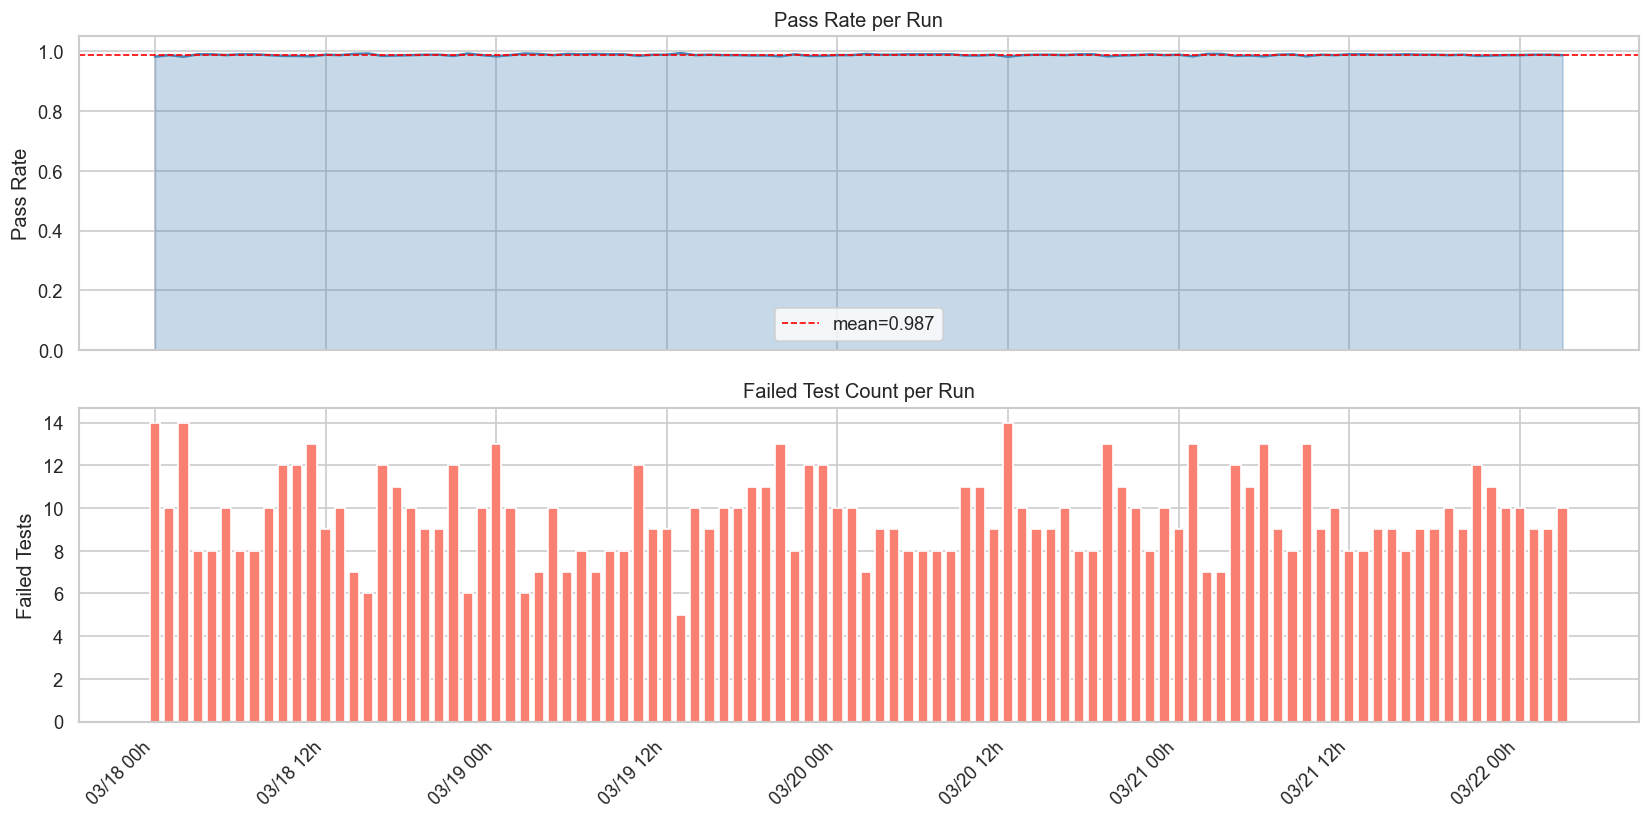

Avg pass rate : 98.736%
Worst run     : run_0000 (14 failures)


In [15]:
run_summary = (
    df.groupby(['run_id', 'run_time'])
    .agg(total=('test_name','count'), passed=('passed','sum'),
         failed=('failed','sum'), skipped=('skipped','sum'))
    .reset_index()
    .sort_values('run_time')
)
run_summary['pass_rate'] = run_summary['passed'] / run_summary['total']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax1.fill_between(run_summary['run_time'], run_summary['pass_rate'], alpha=0.3, color='steelblue')
ax1.plot(run_summary['run_time'], run_summary['pass_rate'], color='steelblue', lw=1.5)
ax1.axhline(run_summary['pass_rate'].mean(), color='red', ls='--', lw=1, label=f"mean={run_summary['pass_rate'].mean():.3f}")
ax1.set_ylabel('Pass Rate'); ax1.set_ylim(0, 1.05); ax1.legend(); ax1.set_title('Pass Rate per Run')

ax2.bar(run_summary['run_time'], run_summary['failed'], color='salmon', width=0.03, label='Failed')
ax2.set_ylabel('Failed Tests'); ax2.set_title('Failed Test Count per Run')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d %Hh'))
fig.autofmt_xdate(rotation=45)
plt.tight_layout()
plt.show()

print(f"Avg pass rate : {run_summary['pass_rate'].mean():.3%}")
print(f"Worst run     : {run_summary.loc[run_summary['failed'].idxmax(), 'run_id']} ({run_summary['failed'].max()} failures)")

## 3 · Flakiness Metrics per Test
A test is **flaky** when `FLAKY_THRESHOLD ≤ fail_rate < BROKEN_THRESHOLD`.  
A test is **broken** when `fail_rate ≥ BROKEN_THRESHOLD`.

In [16]:
test_stats = (
    df[df['outcome'] != 'Skipped']   # exclude skipped from rate denominator
    .groupby('test_name')
    .agg(
        runs        = ('run_id',       'nunique'),
        pass_count  = ('passed',       'sum'),
        fail_count  = ('failed',       'sum'),
        avg_dur_ms  = ('duration_ms',  'mean'),
        p95_dur_ms  = ('duration_ms',  lambda x: x.quantile(0.95)),
        first_fail  = ('run_time',     lambda x: x[df.loc[x.index,'failed']==1].min() if (df.loc[x.index,'failed']==1).any() else pd.NaT),
    )
    .reset_index()
)
test_stats['fail_rate'] = test_stats['fail_count'] / test_stats['runs']

# Filter to tests with enough runs to be statistically meaningful
test_stats = test_stats[test_stats['runs'] >= MIN_RUNS]

def classify(r):
    if r >= BROKEN_THRESHOLD:  return 'broken'
    if r >= FLAKY_THRESHOLD:   return 'flaky'
    return 'stable'

test_stats['status'] = test_stats['fail_rate'].apply(classify)

print(test_stats['status'].value_counts().to_string())
print(f"\n{test_stats[test_stats['status']=='flaky'].shape[0]} flaky, "
      f"{test_stats[test_stats['status']=='broken'].shape[0]} broken tests")

status
stable    736
flaky      20
broken      5

20 flaky, 5 broken tests


## 4 · Top Flaky Tests

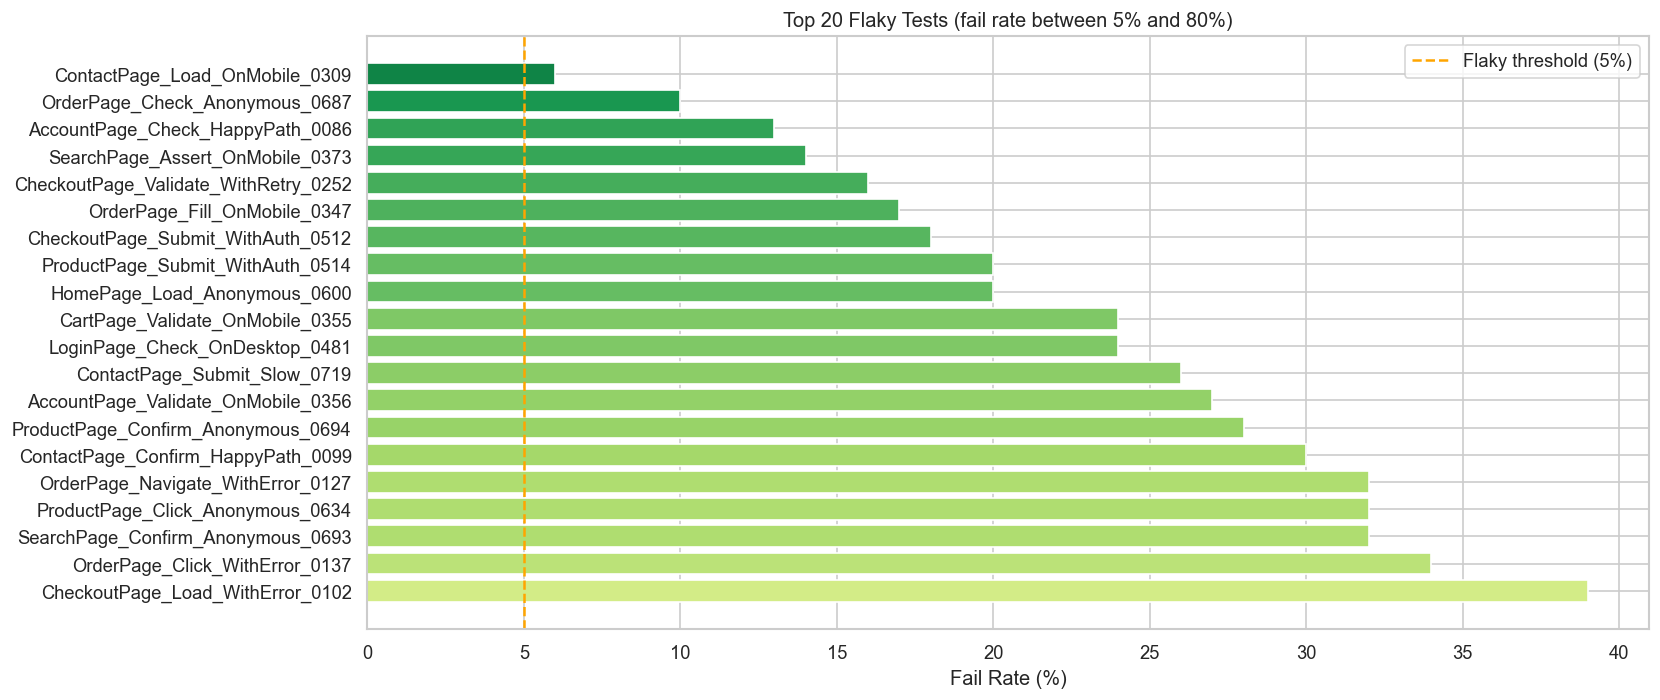

,test_name,runs,fail_count,fail_rate,avg_dur_ms
195,CheckoutPage_Load_WithError_0102,100,39,39.0%,6694 ms
477,OrderPage_Click_WithError_0137,100,34,34.0%,6451 ms
707,SearchPage_Confirm_Anonymous_0693,100,32,32.0%,6189 ms
547,ProductPage_Click_Anonymous_0634,100,32,32.0%,6305 ms
508,OrderPage_Navigate_WithError_0127,100,32,32.0%,5534 ms
251,ContactPage_Confirm_HappyPath_0099,100,30,30.0%,5740 ms
555,ProductPage_Confirm_Anonymous_0694,100,28,28.0%,5456 ms
64,AccountPage_Validate_OnMobile_0356,100,27,27.0%,5746 ms
285,ContactPage_Submit_Slow_0719,100,26,26.0%,5994 ms
390,LoginPage_Check_OnDesktop_0481,100,24,24.0%,5375 ms


In [17]:
flaky_only = test_stats[test_stats['status'] == 'flaky'].sort_values('fail_rate', ascending=False)
top_flaky  = flaky_only.head(TOP_N)

fig, ax = plt.subplots(figsize=(14, 6))
colors = plt.cm.RdYlGn_r(top_flaky['fail_rate'].values)
bars = ax.barh(top_flaky['test_name'], top_flaky['fail_rate'] * 100, color=colors)
ax.axvline(FLAKY_THRESHOLD * 100, color='orange', ls='--', lw=1.5, label=f'Flaky threshold ({FLAKY_THRESHOLD:.0%})')
ax.set_xlabel('Fail Rate (%)')
ax.set_title(f'Top {TOP_N} Flaky Tests (fail rate between {FLAKY_THRESHOLD:.0%} and {BROKEN_THRESHOLD:.0%})')
ax.legend()
plt.tight_layout()
plt.show()

display(top_flaky[['test_name','runs','fail_count','fail_rate','avg_dur_ms']]
        .style.format({'fail_rate':'{:.1%}', 'avg_dur_ms':'{:.0f} ms'})
        .background_gradient(subset=['fail_rate'], cmap='RdYlGn_r'))

## 5 · Flakiness Over Time (Trend)
Are tests getting worse or recovering?

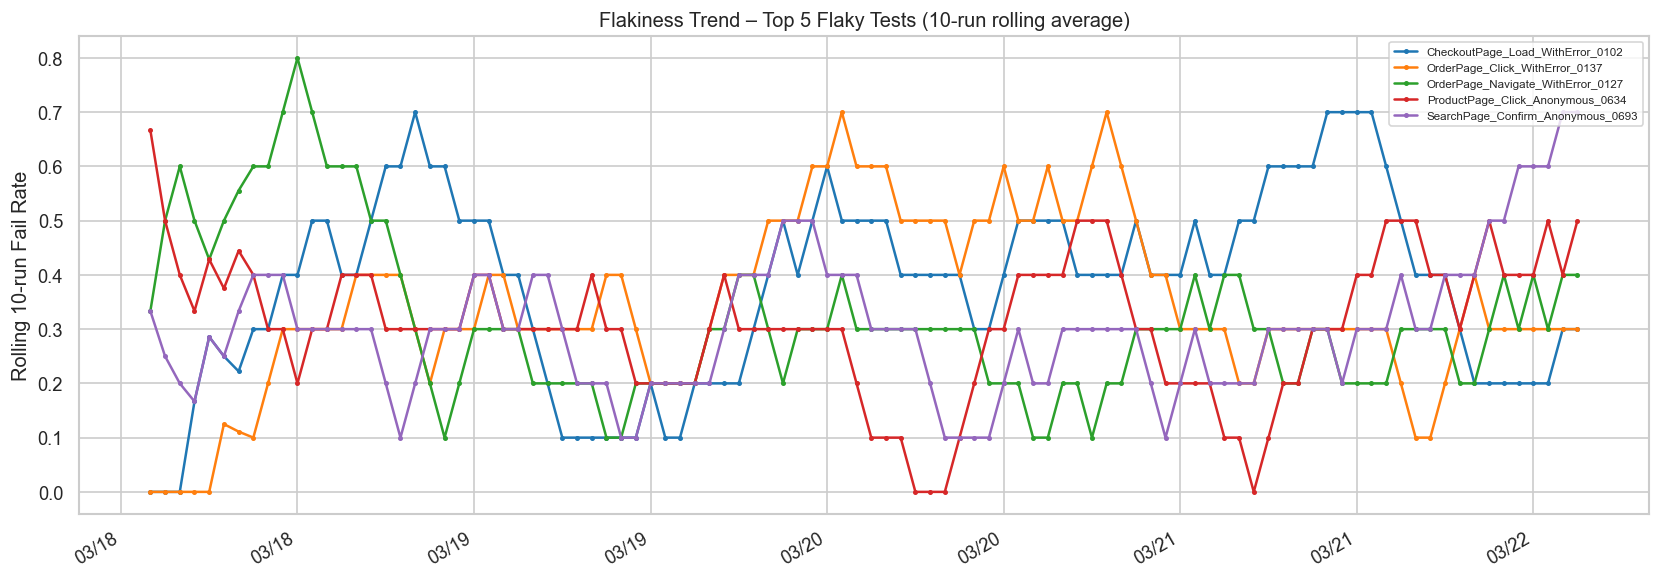

In [18]:
top5_names = top_flaky.head(5)['test_name'].tolist()
trend_df   = df[df['test_name'].isin(top5_names)].sort_values('run_time')

# Rolling 10-run fail rate per test
pivot = (
    trend_df.pivot_table(index='run_time', columns='test_name', values='failed', aggfunc='mean')
    .sort_index()
    .rolling(window=10, min_periods=3)
    .mean()
)

fig, ax = plt.subplots(figsize=(14, 5))
for col in pivot.columns:
    ax.plot(pivot.index, pivot[col], marker='.', ms=4, lw=1.5, label=col[:50])
ax.set_ylabel('Rolling 10-run Fail Rate')
ax.set_title('Flakiness Trend – Top 5 Flaky Tests (10-run rolling average)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
ax.legend(fontsize=7, loc='upper right')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 6 · Co-Failure Heatmap
Tests that fail together suggest a shared infrastructure problem (not individual test flakiness).

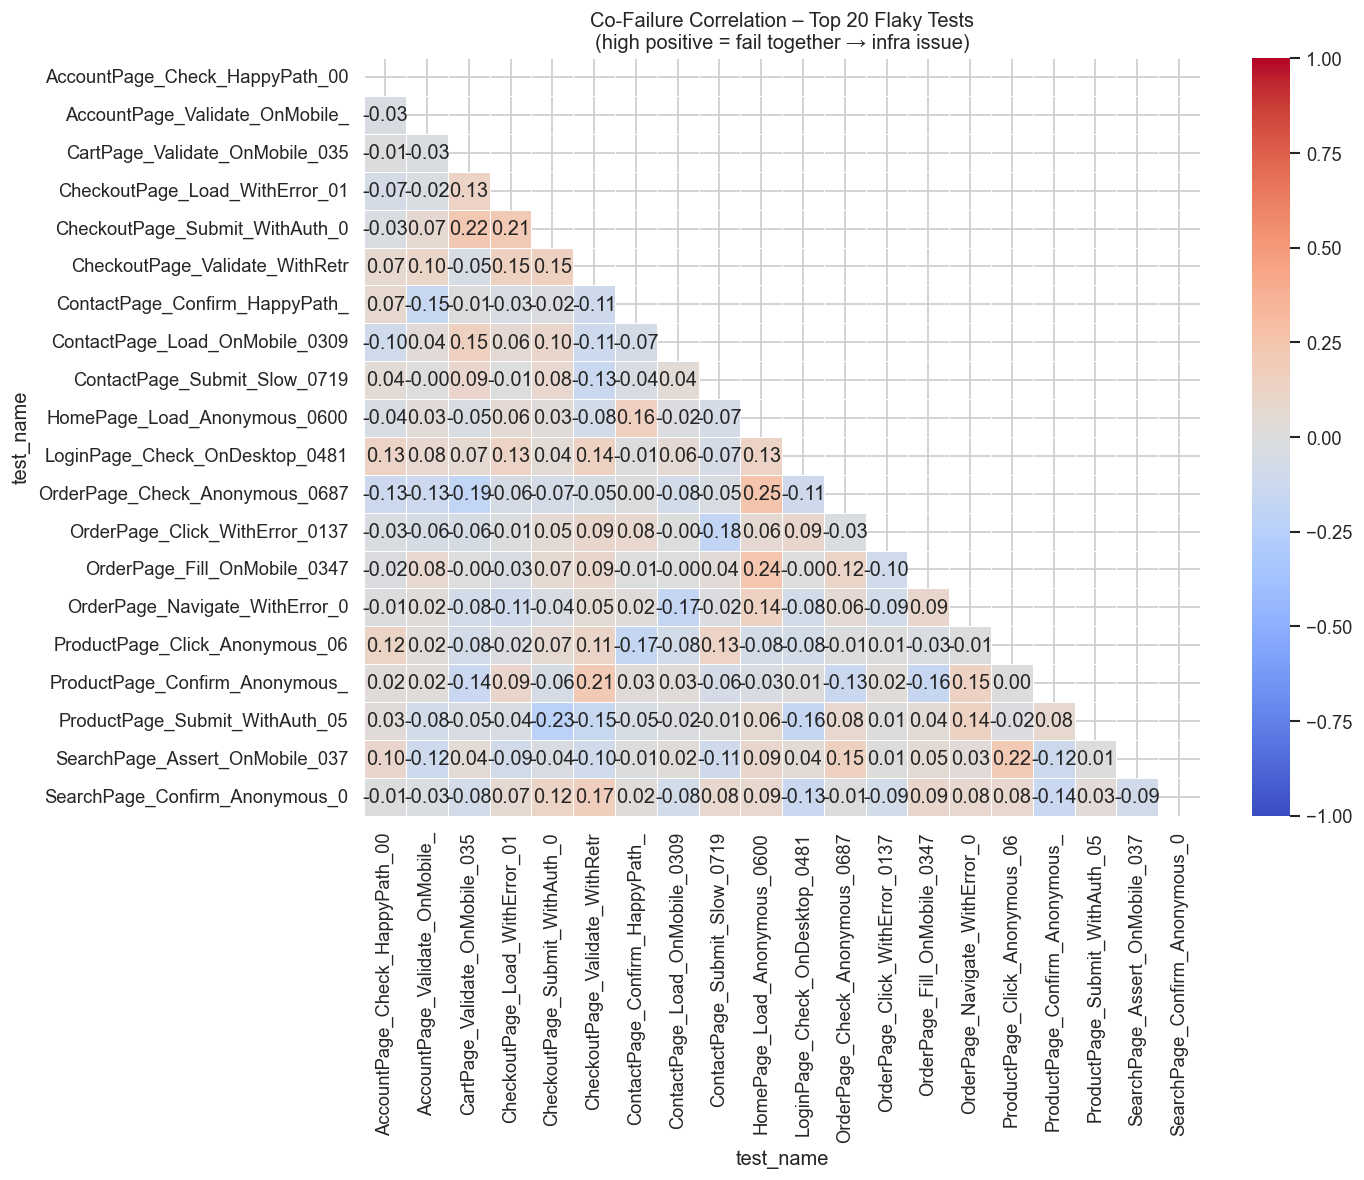

In [19]:
# Use top-20 flaky for the correlation matrix
top20_names = flaky_only.head(20)['test_name'].tolist()
fail_matrix = (
    df[df['test_name'].isin(top20_names)]
    .pivot_table(index='run_id', columns='test_name', values='failed', fill_value=0)
)

corr = fail_matrix.corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', linewidths=0.5, ax=ax,
            xticklabels=[n[:30] for n in corr.columns],
            yticklabels=[n[:30] for n in corr.index])
ax.set_title('Co-Failure Correlation – Top 20 Flaky Tests\n(high positive = fail together → infra issue)')
plt.tight_layout()
plt.show()

## 7 · Duration Analysis
Slow tests are more likely to be flaky due to timeouts. Check if flaky tests run longer on failure.

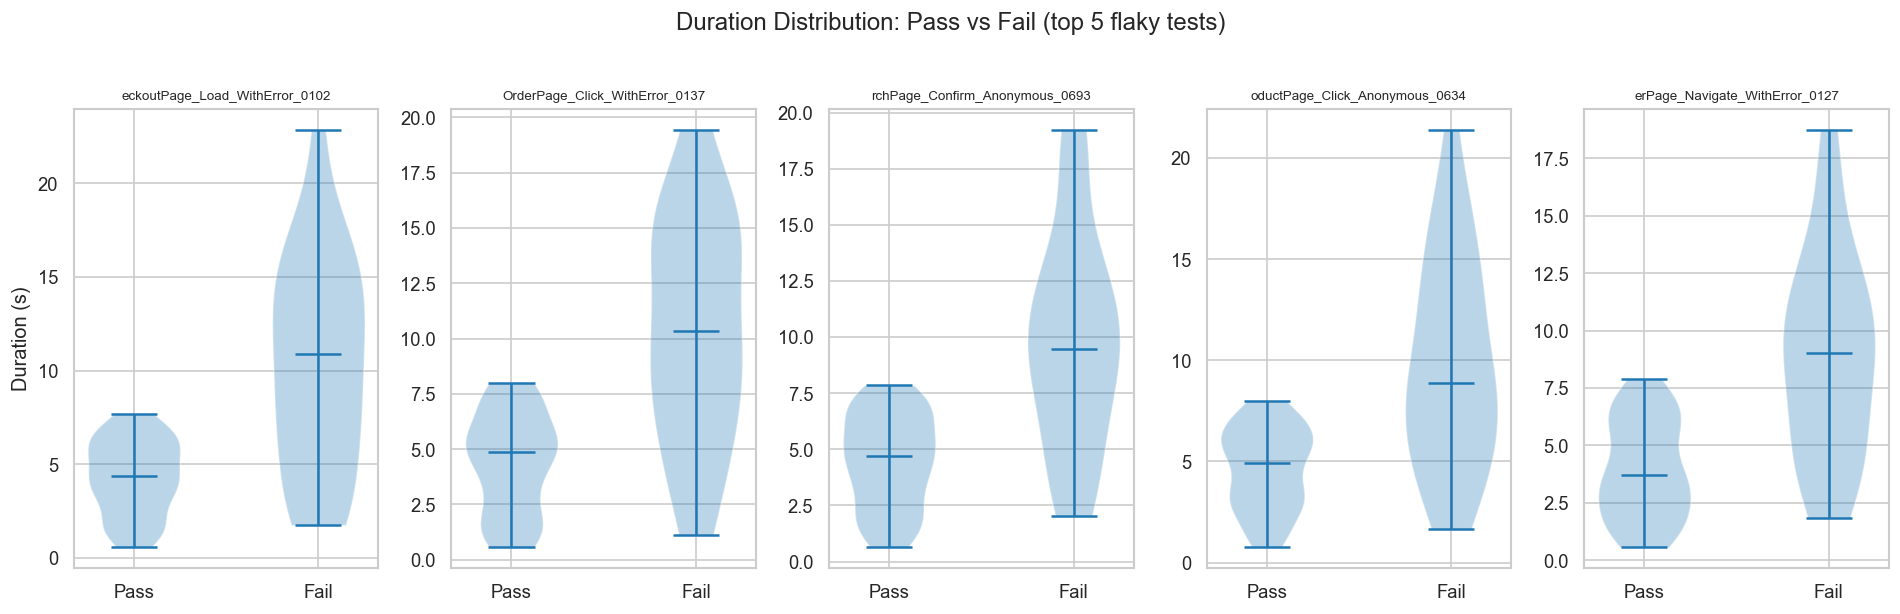

In [20]:
dur_df = df[df['test_name'].isin(top5_names)].copy()
dur_df['outcome_label'] = dur_df['outcome']

fig, axes = plt.subplots(1, len(top5_names), figsize=(16, 5), sharey=False)
for ax, name in zip(axes, top5_names):
    subset = dur_df[dur_df['test_name'] == name]
    pass_dur = subset[subset['outcome']=='Passed']['duration_ms'] / 1000
    fail_dur = subset[subset['outcome']=='Failed']['duration_ms'] / 1000
    ax.violinplot([pass_dur.dropna(), fail_dur.dropna()], showmedians=True)
    ax.set_xticks([1, 2]); ax.set_xticklabels(['Pass', 'Fail'])
    ax.set_title(name[-30:], fontsize=8)
    ax.set_ylabel('Duration (s)' if ax == axes[0] else '')
plt.suptitle('Duration Distribution: Pass vs Fail (top 5 flaky tests)', y=1.02)
plt.tight_layout()
plt.show()

## 8 · Time-of-Day Flakiness Pattern
Are failures clustered at certain hours? Could indicate nightly jobs, traffic peaks, or resource contention.

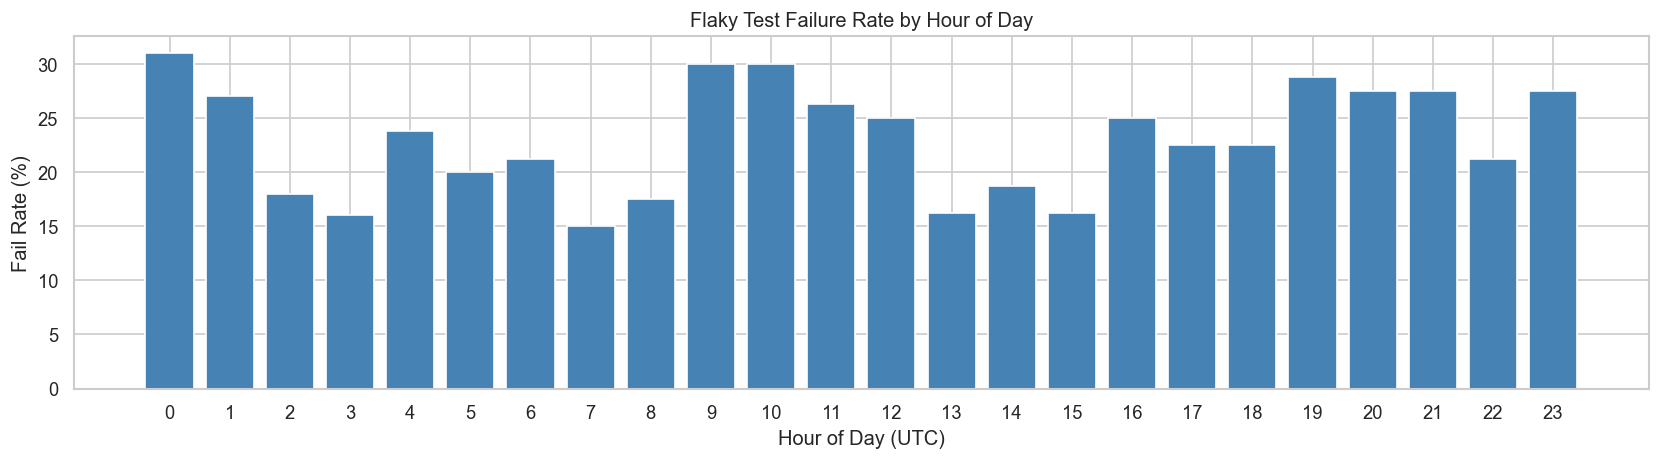

In [21]:
df['hour'] = df['run_time'].dt.hour
hourly = df[df['status'] == 'flaky'] if 'status' in df.columns else df[df['test_name'].isin(flaky_only['test_name'].tolist())]
hourly_fail = (
    hourly.groupby('hour')['failed']
    .agg(['sum','count'])
    .rename(columns={'sum':'failures','count':'total'})
    .reset_index()
)
hourly_fail['fail_rate'] = hourly_fail['failures'] / hourly_fail['total']

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(hourly_fail['hour'], hourly_fail['fail_rate'] * 100, color='steelblue', edgecolor='white')
ax.set_xlabel('Hour of Day (UTC)')
ax.set_ylabel('Fail Rate (%)')
ax.set_title('Flaky Test Failure Rate by Hour of Day')
ax.set_xticks(range(24))
plt.tight_layout()
plt.show()

## 9 · Statistical Significance (Chi-Square)
Is the fail rate higher than the suite average? Only flag tests with p < 0.05.

In [22]:
overall_fail_rate = df['failed'].sum() / len(df)

sig_rows = []
for _, row in flaky_only.iterrows():
    n = row['runs']
    k = row['fail_count']
    expected_fail = n * overall_fail_rate
    expected_pass = n * (1 - overall_fail_rate)
    if expected_fail < 1 or expected_pass < 1:
        continue
    chi2, p = stats.chisquare([k, n - k], f_exp=[expected_fail, expected_pass])
    sig_rows.append({**row.to_dict(), 'chi2': chi2, 'p_value': p, 'significant': p < 0.05})

sig_df = pd.DataFrame(sig_rows).sort_values('p_value')
sig_count = sig_df['significant'].sum()
print(f"Statistically significant flaky tests (p<0.05): {sig_count} / {len(sig_df)}")
display(
    sig_df[sig_df['significant']][['test_name','runs','fail_count','fail_rate','p_value']]
    .head(15)
    .style.format({'fail_rate':'{:.1%}', 'p_value':'{:.4f}'})
)

Statistically significant flaky tests (p<0.05): 20 / 20


,test_name,runs,fail_count,fail_rate,p_value
0,CheckoutPage_Load_WithError_0102,100,39,39.0%,0.0000
1,OrderPage_Click_WithError_0137,100,34,34.0%,0.0000
2,SearchPage_Confirm_Anonymous_0693,100,32,32.0%,0.0000
3,ProductPage_Click_Anonymous_0634,100,32,32.0%,0.0000
4,OrderPage_Navigate_WithError_0127,100,32,32.0%,0.0000
5,ContactPage_Confirm_HappyPath_0099,100,30,30.0%,0.0000
6,ProductPage_Confirm_Anonymous_0694,100,28,28.0%,0.0000
7,AccountPage_Validate_OnMobile_0356,100,27,27.0%,0.0000
8,ContactPage_Submit_Slow_0719,100,26,26.0%,0.0000
10,CartPage_Validate_OnMobile_0355,100,24,24.0%,0.0000


## 10 · Export Prioritized Fix List

In [23]:
# Priority score: higher fail rate + statistically significant → fix first
priority = test_stats[test_stats['status'].isin(['flaky','broken'])].copy()
priority = priority.sort_values(['status','fail_rate'], ascending=[True, False])
priority['priority_rank'] = range(1, len(priority) + 1)

out_path = Path('../data/flaky_tests_report.csv')
priority[['priority_rank','test_name','status','runs','fail_count','fail_rate','avg_dur_ms']].to_csv(out_path, index=False)
print(f'Saved to {out_path}')

display(
    priority[['priority_rank','test_name','status','fail_rate','avg_dur_ms']]
    .head(30)
    .style.format({'fail_rate':'{:.1%}', 'avg_dur_ms':'{:.0f} ms'})
    .map(lambda v: 'background-color: #ffcccc' if v == 'broken' else
                   ('background-color: #ffe8cc' if v == 'flaky' else ''),
         subset=['status'])
)

Saved to ../data/flaky_tests_report.csv


,priority_rank,test_name,status,fail_rate,avg_dur_ms
97,1,CartPage_Click_WithRetry_0235,broken,100.0%,10150 ms
116,2,CartPage_Load_OnMobile_0305,broken,100.0%,9675 ms
233,3,ContactPage_Assert_WithError_0179,broken,100.0%,9097 ms
479,4,OrderPage_Confirm_Anonymous_0697,broken,100.0%,10025 ms
648,5,ProfilePage_Load_OnDesktop_0408,broken,100.0%,8882 ms
195,6,CheckoutPage_Load_WithError_0102,flaky,39.0%,6694 ms
477,7,OrderPage_Click_WithError_0137,flaky,34.0%,6451 ms
508,8,OrderPage_Navigate_WithError_0127,flaky,32.0%,5534 ms
547,9,ProductPage_Click_Anonymous_0634,flaky,32.0%,6305 ms
707,10,SearchPage_Confirm_Anonymous_0693,flaky,32.0%,6189 ms
